In [1]:
# ============================================================
#                  Imports & Drive Paths
# ============================================================

import os, subprocess
# ── Standard Library ────────────────────────────────────────
import sys
import json
import time
import math
import warnings
import itertools
from pathlib import Path
from typing import List, Tuple, Optional, Dict
# ── Numerical / Scientific ───────────────────────────────────
import numpy as np
import pandas as pd
from scipy.ndimage import label
from scipy.spatial.distance import cdist

# ── Visualisation ────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Circle
import matplotlib.ticker as ticker
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401 (side-effect import)

# ── Progress & Utilities ─────────────────────────────────────
from tqdm.notebook import tqdm
from IPython.display import display, clear_output
from joblib import Parallel, delayed # Added for parallel processing

# ── Suppress noisy warnings ──────────────────────────────────
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ============================================================
# Google Drive — Mounting
# ============================================================
ON_COLAB = False

DRIVE_ROOT   = Path('/kaggle/working/radar_placement')
DATA_DIR     = DRIVE_ROOT / 'data'
RESULTS_DIR  = DRIVE_ROOT / 'results'
PLOTS_DIR    = RESULTS_DIR / 'plots'
SRC_DIR      = DRIVE_ROOT / 'src'
CHECKPT_DIR  = RESULTS_DIR / 'checkpoints'

JOBLIB_TEMP_FOLDER = CHECKPT_DIR / 'joblib_tmp'
os.environ['JOBLIB_TEMP_FOLDER'] = str(JOBLIB_TEMP_FOLDER)

for _dir in [DATA_DIR, RESULTS_DIR, PLOTS_DIR, SRC_DIR, CHECKPT_DIR, JOBLIB_TEMP_FOLDER]:
    _dir.mkdir(parents=True, exist_ok=True)

print(f" Project root : {DRIVE_ROOT}")
print(f" Data         : {DATA_DIR}")
print(f" Results      : {RESULTS_DIR}")
print(f" Plots        : {PLOTS_DIR}")
print(f" Checkpoints  : {CHECKPT_DIR}")
print(f" Joblib temp  : {JOBLIB_TEMP_FOLDER}")

# ── Add src/ to Python path for module imports ───────────────
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# ============================================================
# Shared Helper Constants  (non-physics, notebook-level only)
# ============================================================
RANDOM_SEED   = 42
FLOAT_DTYPE   = np.float32          # use float32 throughout to save RAM
INT_DTYPE     = np.int32

FIG_DPI       = 150                 # plot resolution for saved figures
CMAP_TERRAIN  = 'terrain'           # matplotlib colormap for elevation plots
CMAP_COVERAGE = 'RdYlGn'           # colormap for coverage overlays

# ── Timestamp for result filenames ───────────────────────────
RUN_TIMESTAMP = time.strftime('%Y%m%d_%H%M%S')

np.random.seed(RANDOM_SEED)

print(f"\n Random seed  : {RANDOM_SEED}")
print(f"Run timestamp: {RUN_TIMESTAMP}")

 Project root : /kaggle/working/radar_placement
 Data         : /kaggle/working/radar_placement/data
 Results      : /kaggle/working/radar_placement/results
 Plots        : /kaggle/working/radar_placement/results/plots
 Checkpoints  : /kaggle/working/radar_placement/results/checkpoints
 Joblib temp  : /kaggle/working/radar_placement/results/checkpoints/joblib_tmp

 Random seed  : 42
Run timestamp: 20260616_174347


In [2]:
import os

# Find the actual input path
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/notebooks/ananyaa23/radar-deployment/__results__.html
/kaggle/input/notebooks/ananyaa23/radar-deployment/__notebook__.ipynb
/kaggle/input/notebooks/ananyaa23/radar-deployment/__output__.json
/kaggle/input/notebooks/ananyaa23/radar-deployment/custom.css
/kaggle/input/notebooks/ananyaa23/radar-deployment/__results___files/__results___12_3.png
/kaggle/input/notebooks/ananyaa23/radar-deployment/__results___files/__results___12_1.png
/kaggle/input/notebooks/ananyaa23/radar-deployment/__results___files/__results___4_0.png
/kaggle/input/notebooks/ananyaa23/radar-deployment/radar_placement/results/radar_optimization_results_20260616_113036.txt
/kaggle/input/notebooks/ananyaa23/radar-deployment/radar_placement/results/checkpoints/best_positions_fine_flat.npy
/kaggle/input/notebooks/ananyaa23/radar-deployment/radar_placement/results/checkpoints/best_coarse_flat.npy
/kaggle/input/notebooks/ananyaa23/radar-deployment/radar_placement/results/checkpoints/hist_coarse.npy
/kaggle/input/n

In [3]:
# ============================================================
#                    GPU Detection
# ============================================================
from numba import cuda as numba_cuda

try:
    _test_device = numba_cuda.get_current_device()
    GPU_AVAILABLE = True
    print(f"Numba CUDA ready — GPU: {_test_device.name}")
except Exception as e:
    GPU_AVAILABLE = False
    print(f"GPU not available ({e}) — falling back to CPU")

cp = np  # keep cp = np as alias so any leftover cp references don't crash
print("Done.")

Numba CUDA ready — GPU: Tesla T4
Done.


In [4]:
# -- Grid -------------------------------------------------
GRID_SIZE    = 10000
CELL_SIZE_M  = 100          

# -- Terrain ----------------------------------------------
MIN_ELEV     = 10
MAX_ELEV     = 4000

# -- Radar ------------------------------------------------
RADAR_HEIGHT_M   = 3000         
MAX_RANGE_M      = 100_000      
MAX_RANGE_C      = MAX_RANGE_M // CELL_SIZE_M  
# Minimum radar separation
MIN_SEPARATION_M = 150_000       
MIN_SEPARATION_C = MIN_SEPARATION_M // CELL_SIZE_M 

N_RADARS = 5
N_ANGLES = 720

# -- DGO --------------------------------------------------
DGO_ITER            = 300
DGO_BRANCHES        = 40
STAGNATION_LIMIT    = 5
BOOST_FACTOR        = 2
BOOST_DURATION      = 5
MAX_STAGNANT_BOOSTS = 5

# -- Reproducibility --------------------------------------
SEED = 42

In [5]:
# ============================================================
#            Terrain Generation / Loading
# ============================================================
from scipy.ndimage import gaussian_filter

TERRAIN_PATH = DATA_DIR / 'terrain.npy'

def generate_terrain(grid_size, min_elev, max_elev, seed):
    rng = np.random.default_rng(seed)
    noise = rng.random((grid_size, grid_size)).astype(np.float32)

    scale1 = gaussian_filter(noise, sigma=1500)
    scale2 = gaussian_filter(noise, sigma=600)
    scale3 = gaussian_filter(noise, sigma=150)
    terrain  = 0.5 * scale1 + 0.3 * scale2 + 0.2 * scale3
    terrain -= terrain.min()
    terrain /= terrain.max()
    terrain  = terrain * (max_elev - min_elev) + min_elev
    return terrain.astype(np.float32)


if TERRAIN_PATH.exists():
    terrain = np.load(TERRAIN_PATH)
    if terrain.shape == (GRID_SIZE, GRID_SIZE):
        print(f"Loaded terrain from: {TERRAIN_PATH}")
    else:
        print(f"Shape mismatch {terrain.shape}, regenerating...")
        terrain = generate_terrain(GRID_SIZE, MIN_ELEV, MAX_ELEV, SEED)
        np.save(TERRAIN_PATH, terrain)
else:
    print("Generating terrain...")
    terrain = generate_terrain(GRID_SIZE, MIN_ELEV, MAX_ELEV, SEED)
    np.save(TERRAIN_PATH, terrain)
    print(f"Saved to: {TERRAIN_PATH}")

print(f"Terrain shape: {terrain.shape}")
print(f"Elevation range: {terrain.min():.1f}m — {terrain.max():.1f}m")
np.save(CHECKPT_DIR / 'terrain.npy', terrain)
print(f"terrain saved → shape: {terrain.shape}")

Generating terrain...
Saved to: /kaggle/working/radar_placement/data/terrain.npy
Terrain shape: (10000, 10000)
Elevation range: 10.0m — 4000.0m
terrain saved → shape: (10000, 10000)


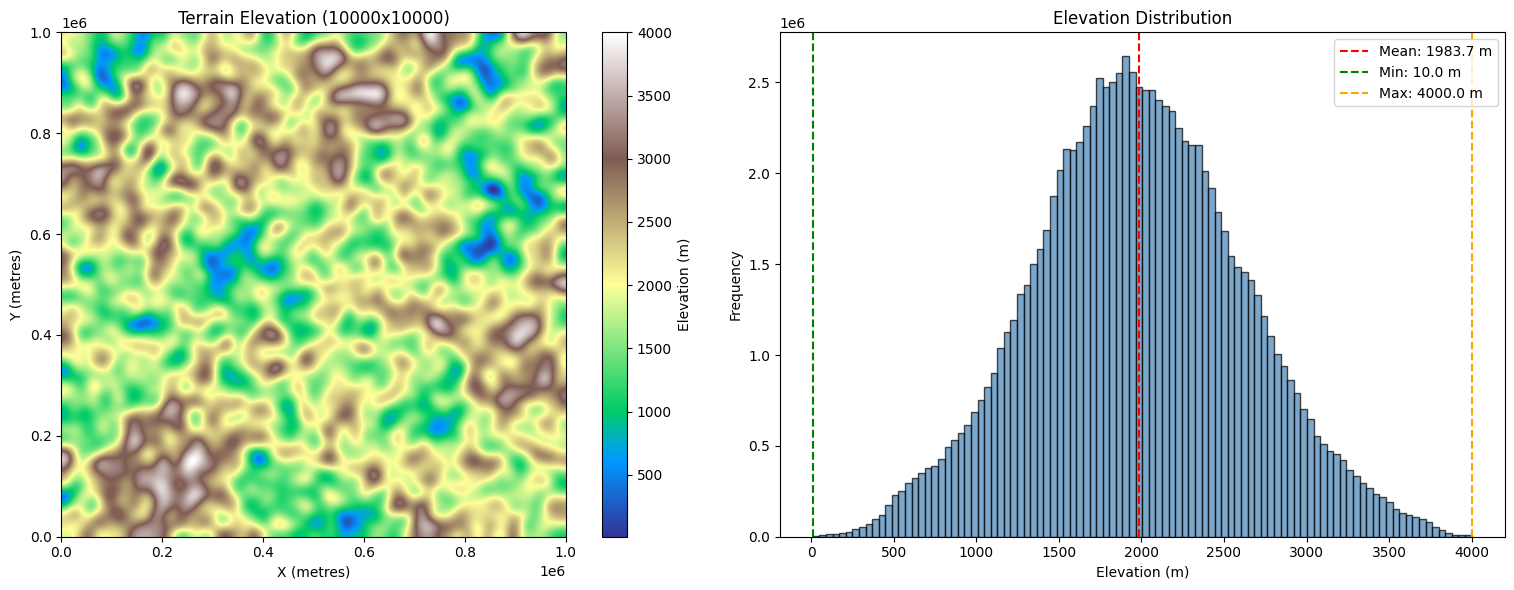

Terrain Statistics:
  Shape: (10000, 10000)
  Min elevation: 10.0 m
  Max elevation: 4000.0 m
  Mean elevation: 1983.7 m
  Std deviation: 632.3 m


In [6]:
# ============================================================
#              CELL 4.5 — Visualize Terrain
# ============================================================

# NOTE: This cell relies on terrain, GRID_SIZE, CELL_SIZE_M, FIG_DPI, PLOTS_DIR, RUN_TIMESTAMP defined previously.

class PlotConfig:
    def __init__(self):
        self.PLOT_SIZE_X = 10
        self.PLOT_SIZE_Y = 8
        self.PLOT_DPI = FIG_DPI

config = PlotConfig()

# Create figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Full Terrain Map ────────────────────────────────
ax1 = axes[0]
im1 = ax1.imshow(terrain, cmap='terrain',
                 extent=[0, GRID_SIZE*CELL_SIZE_M, 0, GRID_SIZE*CELL_SIZE_M])
ax1.set_title(f'Terrain Elevation ({GRID_SIZE}x{GRID_SIZE})')
ax1.set_xlabel('X (metres)')
ax1.set_ylabel('Y (metres)')
plt.colorbar(im1, ax=ax1, label='Elevation (m)')

# ── Plot 2: Elevation Histogram ─────────────────────────────
ax2 = axes[1]
ax2.hist(terrain.flatten(), bins=100, color='steelblue', alpha=0.7, edgecolor='black')
ax2.set_title('Elevation Distribution')
ax2.set_xlabel('Elevation (m)')
ax2.set_ylabel('Frequency')
ax2.axvline(x=terrain.mean(), color='red', linestyle='--', label=f'Mean: {terrain.mean():.1f} m')
ax2.axvline(x=terrain.min(), color='green', linestyle='--', label=f'Min: {terrain.min():.1f} m')
ax2.axvline(x=terrain.max(), color='orange', linestyle='--', label=f'Max: {terrain.max():.1f} m')
ax2.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / f'terrain_overview_{RUN_TIMESTAMP}.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

# ── Print Statistics ────────────────────────────────────────
print(f'Terrain Statistics:')
print(f'  Shape: {terrain.shape}')
print(f'  Min elevation: {terrain.min():.1f} m')
print(f'  Max elevation: {terrain.max():.1f} m')
print(f'  Mean elevation: {terrain.mean():.1f} m')
print(f'  Std deviation: {terrain.std():.1f} m')

In [7]:
# ============================================================
#                      Sanity Checks
# ============================================================

# NOTE: This cell relies on terrain, GRID_SIZE, MIN_ELEV, MAX_ELEV, RADAR_HEIGHT_M, MAX_RANGE_C defined previously.

passed = 0
failed = 0

def check(name, condition, detail=""):
    global passed, failed
    if condition:
        print(f"  PASS | {name}")
        passed += 1
    else:
        print(f"  FAIL | {name}  {detail}")
        failed += 1

print("Running sanity checks...\n")

# -- Terrain shape ----------------------------------------
check(
    "Terrain shape is GRID_SIZE x GRID_SIZE",
    terrain.shape == (GRID_SIZE, GRID_SIZE),
    f"got {terrain.shape}, expected ({GRID_SIZE}, {GRID_SIZE})"
)

# -- Elevation bounds -------------------------------------
check(
    "All elevations >= MIN_ELEV",
    terrain.min() >= MIN_ELEV,
    f"min elevation is {terrain.min():.1f}, expected >= {MIN_ELEV}"
)

check(
    "All elevations <= MAX_ELEV",
    terrain.max() <= MAX_ELEV,
    f"max elevation is {terrain.max():.1f}, expected <= {MAX_ELEV}"
)

# -- Radar height -----------------------------------------
check(
    "RADAR_HEIGHT_M >= MIN_ELEV",
    RADAR_HEIGHT_M >= MIN_ELEV,
    f"RADAR_HEIGHT_M is {RADAR_HEIGHT_M}, MIN_ELEV is {MIN_ELEV}"
)

check(
    "RADAR_HEIGHT_M > terrain minimum",
    RADAR_HEIGHT_M > terrain.min(),
    f"RADAR_HEIGHT_M is {RADAR_HEIGHT_M}, terrain min is {terrain.min():.1f}"
)

# -- MAX_RANGE_C ------------------------------------------
check(
    "MAX_RANGE_C is a positive integer",
    isinstance(MAX_RANGE_C, int) and MAX_RANGE_C > 0,
    f"got {MAX_RANGE_C} of type {type(MAX_RANGE_C)}"
)

check(
    "MAX_RANGE_C does not exceed grid size",
    MAX_RANGE_C <= GRID_SIZE,
    f"MAX_RANGE_C is {MAX_RANGE_C}, GRID_SIZE is {GRID_SIZE}"
)

# -- Summary ----------------------------------------------
print(f"\n{passed} passed, {failed} failed")
if failed == 0:
    print("All checks passed. Safe to proceed.")
else:
    print("Fix the failures above before continuing.")

Running sanity checks...

  PASS | Terrain shape is GRID_SIZE x GRID_SIZE
  PASS | All elevations >= MIN_ELEV
  PASS | All elevations <= MAX_ELEV
  PASS | RADAR_HEIGHT_M >= MIN_ELEV
  PASS | RADAR_HEIGHT_M > terrain minimum
  PASS | MAX_RANGE_C is a positive integer
  PASS | MAX_RANGE_C does not exceed grid size

7 passed, 0 failed
All checks passed. Safe to proceed.


In [8]:
# ============================================================
#                     Viewshed / LoS 
# ============================================================

from numba import cuda
import math as _math

@cuda.jit
def _ray_viewshed_kernel(terrain, obs_r, obs_c, obs_h,
                          max_range_c, n_angles, rows, cols, vis, cell_size_m):
    i = cuda.blockDim.x * cuda.blockIdx.x + cuda.threadIdx.x
    if i >= n_angles:
        return
    angle = 2.0 * _math.pi * i / n_angles
    sin_a = _math.sin(angle)
    cos_a = _math.cos(angle)
    max_slope = -1e30
    for step in range(1, max_range_c + 1):
        ir = int(obs_r + cos_a * step + 0.5)
        ic = int(obs_c + sin_a * step + 0.5)
        if ir < 0 or ir >= rows or ic < 0 or ic >= cols:
            break
        slope = (terrain[ir, ic] - obs_h) / (step * cell_size_m)  # ← fix
        if slope >= max_slope:
            cuda.atomic.or_(vis, (ir, ic), 1)
            max_slope = slope

def compute_viewshed_gpu(terrain, radar_r, radar_c,
                          radar_height_m, max_range_c, n_angles):
    terrain = np.ascontiguousarray(terrain)
    rows, cols = terrain.shape
    obs_h = float(radar_height_m)  # absolute ASL

    terrain_dev = cuda.to_device(terrain)
    vis_dev     = cuda.to_device(np.zeros((rows, cols), dtype=np.int32))

    threads_per_block = 256
    blocks = (n_angles + threads_per_block - 1) // threads_per_block

    _ray_viewshed_kernel[blocks, threads_per_block](
        terrain_dev,
        np.int32(radar_r), np.int32(radar_c), np.float32(obs_h),
        np.int32(max_range_c), np.int32(n_angles),
        np.int32(rows), np.int32(cols),
        vis_dev,
        np.float32(CELL_SIZE_M)
    )

    vis = vis_dev.copy_to_host()

    rr = np.arange(rows)[:, None]
    cc = np.arange(cols)[None, :]
    in_range = (rr - radar_r)**2 + (cc - radar_c)**2 <= max_range_c**2

    result = ((vis > 0) & in_range).astype(np.uint8)
    result[radar_r, radar_c] = 1
    return result
def compute_viewshed(terrain, radar_r, radar_c,
                     radar_height_m, max_range_c, n_angles):
    """CPU fallback for viewshed computation — same logic as GPU kernel."""
    terrain = np.ascontiguousarray(terrain)
    rows, cols = terrain.shape
    obs_h = float(radar_height_m)  # absolute ASL
    vis = np.zeros((rows, cols), dtype=np.int32)

    for i in range(n_angles):
        angle = 2.0 * np.pi * i / n_angles
        sin_a = np.sin(angle)
        cos_a = np.cos(angle)
        max_slope = -1e30

        for step in range(1, max_range_c + 1):
            ir = int(radar_r + cos_a * step + 0.5)
            ic = int(radar_c + sin_a * step + 0.5)
            if ir < 0 or ir >= rows or ic < 0 or ic >= cols:
                break
            slope = (terrain[ir, ic] - obs_h) / (step * CELL_SIZE_M)
            if slope >= max_slope:
                vis[ir, ic] = 1
                max_slope = slope

    # Apply range mask
    rr = np.arange(rows)[:, None]
    cc = np.arange(cols)[None, :]
    in_range = (rr - radar_r)**2 + (cc - radar_c)**2 <= max_range_c**2

    result = ((vis > 0) & in_range).astype(np.uint8)
    result[radar_r, radar_c] = 1
    return result

# Terrain GPU cache (reuse device array across calls)
terrain_gpu_cache = {}

def get_terrain_gpu(terrain):
    key = (terrain.shape, terrain[0,0], terrain[-1,-1])
    if key not in terrain_gpu_cache:
        terrain_gpu_cache[key] = cuda.to_device(terrain)
    return terrain_gpu_cache[key]


def _terrain_hash(terrain):
    return (terrain.shape, float(terrain[0, 0]), float(terrain[500, 500]), float(terrain[-1, -1]))

viewshed_cache = {}

def cached_viewshed(terrain, r, c, radar_height_m, max_range_c, n_angles):
    key = (_terrain_hash(terrain), r, c, radar_height_m, max_range_c, n_angles)
    if key not in viewshed_cache:
        if GPU_AVAILABLE:
            viewshed_cache[key] = compute_viewshed_gpu(
                terrain, r, c, radar_height_m, max_range_c, n_angles
            )
        else:
            viewshed_cache[key] = compute_viewshed(
                terrain, r, c, radar_height_m, max_range_c, n_angles
            )
    return viewshed_cache[key]


# Test it works
if GPU_AVAILABLE:
    print("Testing Numba CUDA viewshed...")
    _test_terrain = np.random.rand(100, 100).astype(np.float32) * 3000
    _test_vis = compute_viewshed_gpu(_test_terrain, 50, 50, 3000.0, 30, 36)
    print(f"  Test passed — visible cells: {_test_vis.sum()}")
else:
    print("GPU not available — cached_viewshed will use CPU fallback.")

Testing Numba CUDA viewshed...


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


  Test passed — visible cells: 163


In [9]:
# ============================================================
#                  CELL 7 — Coverage Model
# ============================================================

# NOTE: This cell relies on cached_viewshed from CELL 6.
def make_disk_mask(max_range_c):
    d = max_range_c
    size = 2 * d + 1
    cy, cx = d, d
    yy = np.arange(size)[:, None]
    xx = np.arange(size)[None, :]
    return ((yy - cy)**2 + (xx - cx)**2) <= d**2

# DISK_MASK is now cached based on max_range_c, not a global constant.
DISK_MASKS_CACHE = {}

def get_disk_mask(max_range_c):
    if max_range_c not in DISK_MASKS_CACHE:
        DISK_MASKS_CACHE[max_range_c] = make_disk_mask(max_range_c)
        # print(f"Cached new DISK_MASK for max_range_c={max_range_c}, shape: {DISK_MASKS_CACHE[max_range_c].shape}") # Debugging line
    return DISK_MASKS_CACHE[max_range_c]

# Removed global DISK_MASK and assert, as they are no longer needed.
# print(f"Disk mask shape: {DISK_MASK.shape}, coverage area: {DISK_MASK.sum()} cells") # Removed

def compute_coverage(terrain, radar_r, radar_c,
                     radar_height_m, max_range_c, n_angles):
    rows, cols = terrain.shape
    d = max_range_c

    current_disk_mask = get_disk_mask(d) # Get the appropriate disk mask

    # Stamp the precomputed disk onto a full-grid boolean array
    in_range = np.zeros((rows, cols), dtype=bool)

    # Compute where the disk lands, clamping to grid edges
    r0, r1 = radar_r - d, radar_r + d + 1
    c0, c1 = radar_c - d, radar_c + d + 1

    # Corresponding slice of the disk (handles edge radars)
    # These indices now correctly refer to the current_disk_mask's dimensions
    dr0 = max(0, -r0);  dr1 = current_disk_mask.shape[0] - max(0, r1 - rows)
    dc0 = max(0, -c0);  dc1 = current_disk_mask.shape[1] - max(0, c1 - cols)

    r0c, r1c = max(0, r0), min(rows, r1)
    c0c, c1c = max(0, c0), min(cols, c1)

    in_range[r0c:r1c, c0c:c1c] = current_disk_mask[dr0:dr1, dc0:dc1]

    # LoS mask unchanged
    los_mask = cached_viewshed(
        terrain, radar_r, radar_c,
        radar_height_m, max_range_c, n_angles
    ).astype(bool)

    coverage = in_range & los_mask
    coverage[radar_r, radar_c] = True
    return coverage

def aggregate_coverage(terrain, radar_positions,
                       radar_height_m, max_range_c, n_angles):
    """
    Union of coverage masks from all radars using logical OR.

    Parameters
    ----------
    radar_positions : list of (row, col) tuples

    Returns
    -------
    combined : 2D bool array
    """
    combined = np.zeros(terrain.shape, dtype=bool)
    for r, c in radar_positions:
        combined |= compute_coverage(
            terrain, r, c,
            radar_height_m, max_range_c, n_angles
        )
    return combined

In [10]:
# ============================================================
#                CELL 8 — Fitness Function
# ============================================================

# NOTE: This cell relies on aggregate_coverage from CELL 7.

def fitness(flat_positions, terrain,
            radar_height_m, max_range_c,
            n_angles, min_separation_c):
    """
    Score a candidate radar layout.

    Score = covered cells / total cells, minus penalties.
    Penalty of 0.1 per radar that is out of bounds or
    closer than min_separation_c cells to another radar.

    Parameters
    ----------
    flat_positions : 1D int array [r1, c1, r2, c2, ...]

    Returns
    -------
    score : float in [0, 1], higher is better
    """
    rows, cols = terrain.shape
    n          = len(flat_positions) // 2
    positions  = flat_positions.reshape(n, 2)
    penalty    = 0.0

    # out of bounds
    for r, c in positions:
        if r < 0 or r >= rows or c < 0 or c >= cols:
            penalty += 0.1

    # proximity
    dists = cdist(positions.astype(float), positions.astype(float))
    np.fill_diagonal(dists, np.inf)
    penalty += 0.5 * np.sum(dists < min_separation_c) / 2

    clipped    = np.clip(positions, [0, 0], [rows - 1, cols - 1])
    radar_list = [(int(r), int(c)) for r, c in clipped]

    coverage   = aggregate_coverage(
        terrain, radar_list,
        radar_height_m, max_range_c, n_angles
    )

    score = coverage.sum() / coverage.size
    return max(0.0, score - penalty)

In [11]:
# ============================================================
#                   CELL 9 — DGO Optimizer
# ============================================================

import numpy as np


def run_dgo(terrain,
            n_radars, radar_height_m, max_range_c,
            n_angles, min_separation_c,
            dgo_iter, dgo_branches,
            stagnation_limit, boost_factor, boost_duration,
            max_stagnant_boosts,
            seed, n_jobs=-1, initial_positions=None):
    """
    Dendritic Growth Optimization for radar placement.

    Returns
    -------
    best_positions : 1D int array [r1, c1, r2, c2, ...]
    best_score     : float
    history        : list of best score per iteration
    """
    rng        = np.random.default_rng(seed)
    rows, cols = terrain.shape

    if initial_positions is not None:
        # Use provided initial positions, ensuring they are valid
        best = np.array(initial_positions, dtype=np.int32).flatten()
        best[0::2] = np.clip(best[0::2], 0, rows - 1)
        best[1::2] = np.clip(best[1::2], 0, cols - 1)
    else:
        # Random initialization as before
        best        = np.empty(n_radars * 2, dtype=np.int32)
        best[0::2]  = rng.integers(0, rows, size=n_radars)
        best[1::2]  = rng.integers(0, cols, size=n_radars)

    best_score = fitness(
        best, terrain,
        radar_height_m, max_range_c,
        n_angles, min_separation_c
    )

    history          = [best_score]
    stagnation_count = 0
    boost_remaining  = 0
    stagnant_boost_counter = 0 # New: counts boosts with no score improvement
    best_score_at_last_boost = best_score # New: tracks score at last boost activation

    # Confirm joblib temp folder for debugging
    print(f"Joblib Parallel using temp_folder: {os.environ.get('JOBLIB_TEMP_FOLDER', 'Default (likely /tmp)')}")

    for i in range(dgo_iter):
        progress = i / max(dgo_iter - 1, 1)

        if boost_remaining > 0:
            branches     = dgo_branches * boost_factor
            perturb_size = max(2, int(min(rows, cols) * 0.3))
            boost_remaining -= 1
        else:
            branches     = max(2, int(dgo_branches * (1 - progress))) # Ensure at least 2 branches
            perturb_size = max(2, int(min(rows, cols) * (1 - progress) * 0.5))

        candidates = []
        for _ in range(branches):
            noise           = rng.integers(-perturb_size, perturb_size + 1,
                                           size=best.shape)
            candidate       = best + noise
            candidate[0::2] = np.clip(candidate[0::2], 0, rows - 1)
            candidate[1::2] = np.clip(candidate[1::2], 0, cols - 1)
            candidates.append(candidate.astype(np.int32))

        # Parallelize fitness evaluation, explicitly passing temp_folder
        # --- FIXED: parallel fitness evaluation (was sequential) ---
        scores = Parallel(n_jobs=-1, temp_folder=str(JOBLIB_TEMP_FOLDER))(
            delayed(fitness)(c, terrain, radar_height_m, max_range_c,
                             n_angles, min_separation_c)
            for c in candidates
        )

        best_idx        = int(np.argmax(scores))
        iter_best_score = scores[best_idx]

        if iter_best_score > best_score:
            best             = candidates[best_idx]
            best_score       = iter_best_score
            stagnation_count = 0
            stagnant_boost_counter = 0 # Reset stagnant boosts if real improvement occurs
        else:
            stagnation_count += 1

        if stagnation_count >= stagnation_limit:
            # Check if score improved since the last time a boost was activated
            if best_score <= best_score_at_last_boost:
                stagnant_boost_counter += 1
                print(f"  iter {i:04d} | Score did not improve after boost, {stagnant_boost_counter}/{max_stagnant_boosts} stagnant boosts")
                if stagnant_boost_counter >= max_stagnant_boosts:
                    print(f"  iter {i:04d} | Optimization stopped due to prolonged stagnation after {max_stagnant_boosts} boosts.")
                    break # Stop the optimization
            else:
                # Score improved since last boost, reset counter and update reference
                stagnant_boost_counter = 0
                best_score_at_last_boost = best_score

            boost_remaining  = boost_remaining + boost_duration
            stagnation_count = 0
            print(f"  iter {i:04d} | stagnation detected, boosting exploration")

        history.append(best_score)
        print(f"  iter {i:04d} | branches {branches:02d} | "
              f"perturb {perturb_size:04d} | score {best_score:.4f}")

    return best, best_score, history


# ============================================================
#             CELL 9.5 — Greedy Initialization
# ============================================================

def greedy_init(terrain, n_radars, radar_height_m, max_range_c, n_angles, min_separation_c, num_candidates=1000):
    rows, cols = terrain.shape
    positions_list = []

    # Store only the SPARSE set of covered cell indices, not full grid
    covered_array = np.zeros(rows * cols, dtype=bool)
    total_cells = rows * cols

    print(f"  Starting greedy initialization for {n_radars} radars...")

    flat_terrain = terrain.flatten()
    candidate_flat_indices = np.argpartition(flat_terrain, -num_candidates)[-num_candidates:]

    for i in range(n_radars):
        best_r, best_c, best_gain = -1, -1, -1
        best_visible_indices = None

        for flat_idx in candidate_flat_indices:
            r, c = divmod(int(flat_idx), cols)

            # Separation check
            too_close = False
            for pr, pc in zip(positions_list[0::2], positions_list[1::2]):
                if ((r - pr)**2 + (c - pc)**2)**0.5 < min_separation_c:
                    too_close = True
                    break
            if too_close:
                continue

            # Get viewshed — uint8, compact
            vis = cached_viewshed(terrain, r, c, radar_height_m, max_range_c, n_angles)

            # Convert to sparse indices immediately, discard full array
            visible_flat = np.flatnonzero(vis)

            # Marginal gain = visible cells not already covered
            new_cells = int(np.sum(~covered_array[visible_flat]))

            if new_cells > best_gain:
                best_r, best_c, best_gain = r, c, new_cells
                best_visible_indices = visible_flat

        if best_r == -1:
            best_r = np.random.randint(0, rows)
            best_c = np.random.randint(0, cols)
            vis = cached_viewshed(terrain, best_r, best_c, radar_height_m, max_range_c, n_angles)
            best_visible_indices = np.flatnonzero(vis)
            print(f"  Warning: fallback random placement for radar {i+1}")

        positions_list.extend([best_r, best_c])
        covered_array[best_visible_indices] = True
        print(f"  Greedy placed radar {i+1} at ({best_r}, {best_c}) with marginal gain {best_gain}")

    return np.array(positions_list, dtype=np.int32).flatten()

In [12]:
import psutil, gc

ram = psutil.virtual_memory()
print(f"RAM used: {ram.used/1e9:.1f}GB / {ram.total/1e9:.1f}GB ({ram.percent}%)")

try:
    from numba import cuda
    free, total = cuda.current_context().get_memory_info()
    print(f"VRAM free: {free/1e9:.1f}GB / {total/1e9:.1f}GB")
except Exception as e:
    print(f"GPU memory check failed: {e}")

print(f"\nTerrain: {terrain.shape}, dtype={terrain.dtype}")
print(f"GPU_AVAILABLE: {GPU_AVAILABLE}")

viewshed_cache.clear()
gc.collect()
print("Cache cleared, ready for Cell 10")

RAM used: 2.2GB / 33.7GB (7.9%)
VRAM free: 15.5GB / 15.6GB

Terrain: (10000, 10000), dtype=float32
GPU_AVAILABLE: True
Cache cleared, ready for Cell 10


In [13]:
# ============================================================
#             CELL 10 — Two-Stage DGO Execution
# ============================================================

# NOTE: This cell relies on many constants from CELL 2, terrain from CELL 4, and
#       the run_dgo and greedy_init functions from CELL 9 and 9.5.

# Define coarse factor and derived parameters
FACTOR = 4 # Downsampling factor

terrain_coarse = terrain[::FACTOR, ::FACTOR]

rows_coarse, cols_coarse = terrain_coarse.shape

# Scale parameters for the coarse search
max_range_c_coarse = MAX_RANGE_C // FACTOR
n_angles_coarse    = max(12, N_ANGLES // FACTOR)
min_separation_c_coarse = max(1, MIN_SEPARATION_C // FACTOR)

# Reduce iterations and branches for coarse run
dgo_iter_coarse = DGO_ITER // 2
dgo_branches_coarse = max(10, DGO_BRANCHES // 2)

print(f"Coarse terrain shape: {terrain_coarse.shape}")
print(f"Coarse max range (cells): {max_range_c_coarse}")
print(f"Coarse N_ANGLES: {n_angles_coarse}")
print(f"Coarse min separation (cells): {min_separation_c_coarse}")
print(f"Coarse DGO iterations: {dgo_iter_coarse}")
print(f"Coarse DGO branches: {dgo_branches_coarse}")

# Generate initial positions using the greedy strategy for the coarse run
print("\nGenerating initial positions for coarse DGO using greedy approach...")
greedy_initial_coarse_flat = greedy_init(
    terrain_coarse, N_RADARS, RADAR_HEIGHT_M, max_range_c_coarse,
    n_angles_coarse, min_separation_c_coarse
)

# Run DGO on the coarse terrain with greedy initialization
print("\nStarting coarse DGO run with greedy initialization...")
best_coarse_flat, score_coarse, hist_coarse = run_dgo(
    terrain_coarse, N_RADARS, RADAR_HEIGHT_M, max_range_c_coarse,
    n_angles_coarse, min_separation_c_coarse,
    dgo_iter_coarse, dgo_branches_coarse,
    STAGNATION_LIMIT, BOOST_FACTOR, BOOST_DURATION,
    MAX_STAGNANT_BOOSTS, SEED,
    initial_positions=greedy_initial_coarse_flat
)

print(f"Coarse DGO complete. Best coarse score: {score_coarse:.4f}")
best_coarse_positions = best_coarse_flat.reshape(N_RADARS, 2)
print(f"Optimal coarse radar positions (row, col):\n{best_coarse_positions}")

# 2. Map coarse positions back to full grid with local jitter search
best_coarse_positions = best_coarse_flat.reshape(N_RADARS, 2)

# Offsets to try around each mapped position (in full-grid cells)
JITTER_OFFSETS = np.array([
    [0, 0], [1, 0], [-1, 0], [0, 1], [0, -1],
    [1, 1], [-1, 1], [1, -1], [-1, -1],
    [2, 0], [-2, 0], [0, 2], [0, -2],
])

print("\nSearching for best jitter offset for each radar position...")
best_full_init = np.empty_like(best_coarse_positions)

for i, (cr, cc) in enumerate(best_coarse_positions):
    # Map to full grid
    base_r = int(np.clip(cr * FACTOR, 0, terrain.shape[0] - 1))
    base_c = int(np.clip(cc * FACTOR, 0, terrain.shape[1] - 1))

    best_jitter_score = -1
    best_jr, best_jc = base_r, base_c

    # Build a temporary position array with this radar varied
    temp_positions = best_coarse_positions.copy() * FACTOR
    temp_positions = np.clip(temp_positions, [0, 0],
                             [terrain.shape[0]-1, terrain.shape[1]-1]).astype(np.int32)

    for dr, dc in JITTER_OFFSETS:
        jr = int(np.clip(base_r + dr, 0, terrain.shape[0] - 1))
        jc = int(np.clip(base_c + dc, 0, terrain.shape[1] - 1))
        temp_positions[i] = [jr, jc]

        s = fitness(temp_positions.flatten(), terrain,
                    RADAR_HEIGHT_M, MAX_RANGE_C, N_ANGLES, MIN_SEPARATION_C)
        if s > best_jitter_score:
            best_jitter_score = s
            best_jr, best_jc = jr, jc

    best_full_init[i] = [best_jr, best_jc]
    print(f"  Radar {i+1}: coarse ({cr},{cc}) → mapped ({base_r},{base_c}) "
          f"→ jitter-best ({best_jr},{best_jc})")

best_full_init = best_full_init.astype(np.int32)

initial_full_grid_score = fitness(
    best_full_init.flatten(), terrain,
    RADAR_HEIGHT_M, MAX_RANGE_C, N_ANGLES, MIN_SEPARATION_C
)
print(f"\nFitness after jitter refinement on full grid: {initial_full_grid_score:.4f}")

np.save(CHECKPT_DIR / 'best_coarse_flat.npy', best_coarse_flat)
print("Coarse results saved.")
np.save(CHECKPT_DIR / 'hist_coarse.npy', np.array(hist_coarse))
np.save(CHECKPT_DIR / 'terrain.npy', terrain)
# Fine DGO run
print("\nStarting fine DGO refinement run...")

best_positions_fine_flat, best_score_fine, hist_fine = run_dgo(
    terrain, N_RADARS, RADAR_HEIGHT_M, MAX_RANGE_C,
    N_ANGLES, MIN_SEPARATION_C,
    DGO_ITER, DGO_BRANCHES,
    STAGNATION_LIMIT, BOOST_FACTOR, BOOST_DURATION,
    MAX_STAGNANT_BOOSTS, SEED,
    initial_positions=best_full_init
)

print(f"Fine DGO complete. Best fine score: {best_score_fine:.4f}")
np.save(CHECKPT_DIR / 'best_positions_fine_flat.npy', best_positions_fine_flat)
np.save(CHECKPT_DIR / 'hist_fine.npy', hist_fine)
print("Fine results saved.")
best_positions_fine = best_positions_fine_flat.reshape(N_RADARS, 2)
print(f"Optimal refined radar positions (row, col):\n{best_positions_fine}")


Coarse terrain shape: (2500, 2500)
Coarse max range (cells): 250
Coarse N_ANGLES: 180
Coarse min separation (cells): 375
Coarse DGO iterations: 150
Coarse DGO branches: 20

Generating initial positions for coarse DGO using greedy approach...
  Starting greedy initialization for 5 radars...
  Greedy placed radar 1 at (2107, 651) with marginal gain 9
  Greedy placed radar 2 at (863, 1037) with marginal gain -1
  Greedy placed radar 3 at (594, 1182) with marginal gain -1
  Greedy placed radar 4 at (1517, 1352) with marginal gain -1
  Greedy placed radar 5 at (613, 1872) with marginal gain -1

Starting coarse DGO run with greedy initialization...
Joblib Parallel using temp_folder: /kaggle/working/radar_placement/results/checkpoints/joblib_tmp


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPe

  iter 0000 | branches 20 | perturb 1250 | score 0.0281


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPe

  iter 0001 | branches 19 | perturb 1241 | score 0.0281


...

  iter 0022 | branches 80 | perturb 3000 | score 0.0281


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 3 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 3 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 3 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 3 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPe

  iter 0023 | branches 80 | perturb 3000 | score 0.0281


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 3 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 3 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 3 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 3 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPe

  iter 0024 | Score did not improve after boost, 5/5 stagnant boosts
  iter 0024 | Optimization stopped due to prolonged stagnation after 5 boosts.
Fine DGO complete. Best fine score: 0.0281
Fine results saved.
Optimal refined radar positions (row, col):
[[7824 4290]
 [4997 3860]
 [5930 5380]
 [1862 8060]
 [3202 8836]]


In [14]:
viewshed_cache.clear()
import gc
gc.collect()
print("Cache cleared")

Cache cleared


Terrain downsampled: (10000, 10000) → (1000, 1000)
Max range scaled:    1000 cells → 100 cells (viz)
Computing coverage masks on original terrain...
  R1: 476198 cells covered (0.48% of full grid)
  R2: 612773 cells covered (0.61% of full grid)
  R3: 534509 cells covered (0.53% of full grid)
  R4: 588644 cells covered (0.59% of full grid)
  R5: 599513 cells covered (0.60% of full grid)
Total combined coverage: 2.81%


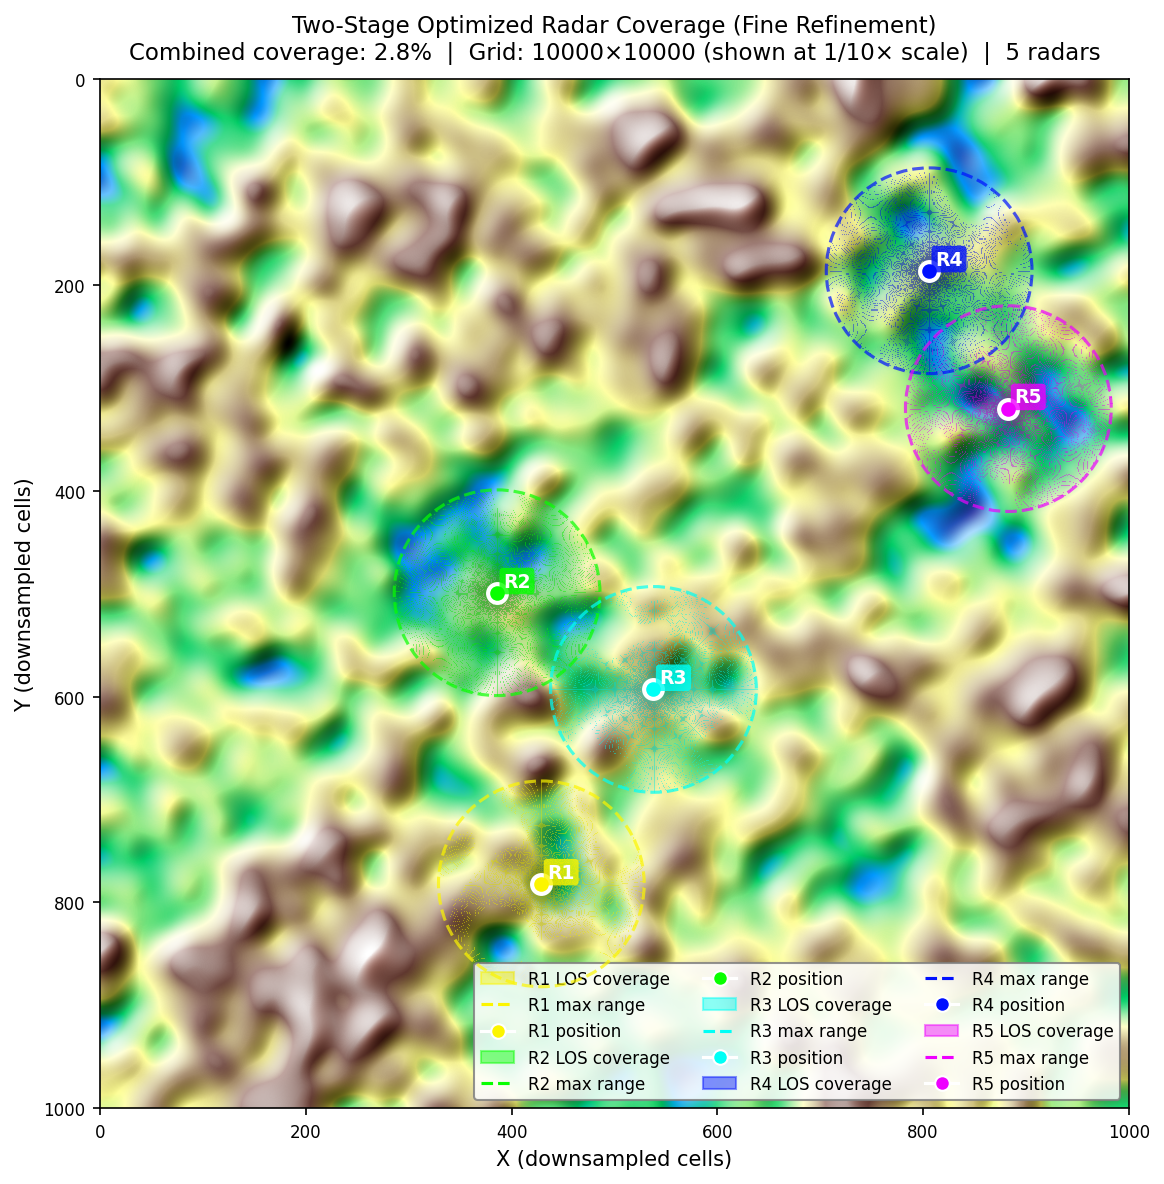

Plot saved → /kaggle/working/radar_placement/results/plots/radar_coverage_map_20260616_174347.png


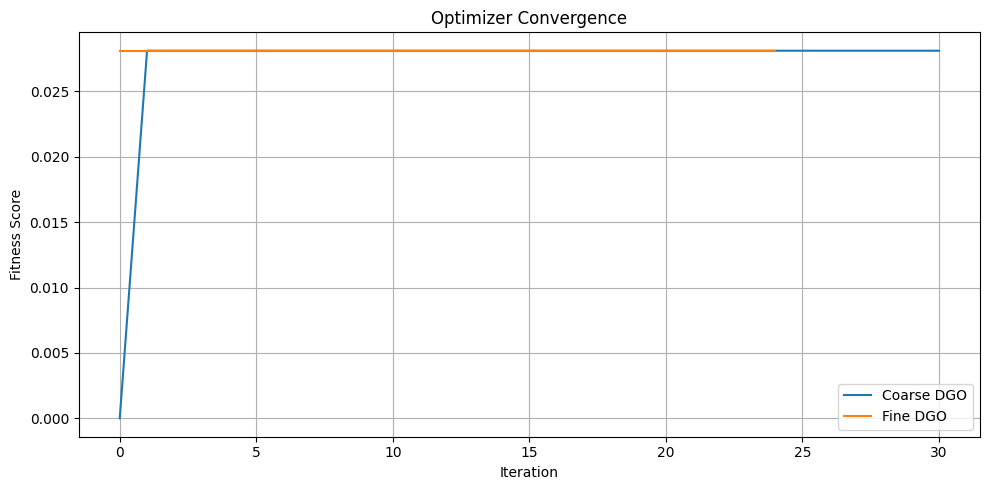

Plot saved → /kaggle/working/radar_placement/results/plots/convergence_20260616_174347.png

Two-Stage Optimization Results:
  Grid size               : 10000×10000 cells (1000×1000 km)
  Number of radars        : 5
  Max radar range         : 100.0 km
  Combined coverage       : 2.81%
  Radar positions (row, col):
    R1: (7824, 4290)
    R2: (4997, 3860)
    R3: (5930, 5380)
    R4: (1862, 8060)
    R5: (3202, 8836)


In [15]:
# ============================================================
#                  CELL 11 — Visualizations
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import LightSource
from scipy.ndimage import gaussian_filter
import numpy as np
import time
from pathlib import Path

# ============================================================
#         SECTION 1 — Robustness Guards
# ============================================================

if 'ON_COLAB' not in globals():
    try:
        from google.colab import drive
        ON_COLAB = True
    except ModuleNotFoundError:
        ON_COLAB = False
    print("WARNING: ON_COLAB was not found. Re-initializing.")

if 'DRIVE_ROOT' not in globals():
    DRIVE_ROOT = Path('/content/drive/MyDrive/radar_placement') if ON_COLAB else Path('/kaggle/working/radar_placement')
    print(f"WARNING: DRIVE_ROOT re-initialized to: {DRIVE_ROOT}")

if 'RESULTS_DIR' not in globals():
    RESULTS_DIR = DRIVE_ROOT / 'results'
    print(f"WARNING: RESULTS_DIR re-initialized to: {RESULTS_DIR}")

if 'PLOTS_DIR' not in globals():
    PLOTS_DIR = RESULTS_DIR / 'plots'
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    print(f"WARNING: PLOTS_DIR re-initialized to: {PLOTS_DIR}")

if 'CHECKPT_DIR' not in globals():
    CHECKPT_DIR = RESULTS_DIR / 'checkpoints'
    CHECKPT_DIR.mkdir(parents=True, exist_ok=True)
    print(f"WARNING: CHECKPT_DIR re-initialized to: {CHECKPT_DIR}")

if 'N_RADARS' not in globals():
    N_RADARS = 5
    print(f"WARNING: N_RADARS re-initialized to: {N_RADARS}")

if 'RUN_TIMESTAMP' not in globals():
    RUN_TIMESTAMP = time.strftime('%Y%m%d_%H%M%S')
    print(f"WARNING: RUN_TIMESTAMP re-initialized to: {RUN_TIMESTAMP}")

if 'FIG_DPI' not in globals():
    FIG_DPI = 150
    print(f"WARNING: FIG_DPI re-initialized to: {FIG_DPI}")

if 'CELL_SIZE_M' not in globals():
    CELL_SIZE_M = 100
    print(f"WARNING: CELL_SIZE_M re-initialized to: {CELL_SIZE_M}")

if 'RADAR_HEIGHT_M' not in globals():
    RADAR_HEIGHT_M = 3000
    print(f"WARNING: RADAR_HEIGHT_M re-initialized to: {RADAR_HEIGHT_M}")

if 'MAX_RANGE_C' not in globals():
    MAX_RANGE_C = 1000
    print(f"WARNING: MAX_RANGE_C re-initialized to: {MAX_RANGE_C}")

if 'N_ANGLES' not in globals():
    N_ANGLES = 720
    print(f"WARNING: N_ANGLES re-initialized to: {N_ANGLES}")

if 'terrain' not in globals():
    terrain_path = CHECKPT_DIR / 'terrain.npy'
    if terrain_path.exists():
        terrain = np.load(terrain_path)
        print(f"WARNING: terrain reloaded from checkpoint. Shape: {terrain.shape}")
    else:
        raise RuntimeError(
            "terrain not found in globals and no terrain.npy in checkpoint dir.\n"
            "Re-run the terrain generation cell first."
        )

# Dummy config fallback (Cell 2 uses loose variables, not a config object)
class _Config:
    PLOT_SIZE_X = 14
    PLOT_SIZE_Y = 10
    PLOT_DPI    = 150

if 'config' not in globals():
    config = _Config()
    print("WARNING: config not found. Using default plot dimensions.")

if 'compute_coverage' not in globals():
    raise RuntimeError(
        "compute_coverage not found.\n"
        "Re-run the cell that defines it before running this cell."
    )

# ============================================================
#         SECTION 2 — Reload checkpoint if state was lost
# ============================================================

_needs_reload = False
try:
    best_positions_fine
except NameError:
    _needs_reload = True

if _needs_reload:
    print("Variables lost — reloading from checkpoint...")
    fine_path   = CHECKPT_DIR / 'best_positions_fine_flat.npy'
    coarse_path = CHECKPT_DIR / 'hist_coarse.npy'
    fine_h_path = CHECKPT_DIR / 'hist_fine.npy'

    missing = [p for p in [fine_path, coarse_path, fine_h_path] if not p.exists()]
    if missing:
        print(f"WARNING: Missing checkpoint files — using hardcoded fallback:\n"
              + "\n".join(str(p) for p in missing))
        best_positions_fine = np.array([
            [6439, 4876],
            [5724, 7474],
            [6049, 9025],
            [3600, 1806],
            [1208, 2597]
        ])
        hist_coarse = []
        hist_fine   = []
    else:
        best_positions_fine_flat = np.load(fine_path)
        best_positions_fine      = best_positions_fine_flat.reshape(N_RADARS, 2)
        hist_coarse              = np.load(coarse_path).tolist()
        hist_fine                = np.load(fine_h_path).tolist()
        print(f"Reloaded. positions shape: {best_positions_fine.shape}, "
              f"hist_coarse: {len(hist_coarse)} iters, hist_fine: {len(hist_fine)} iters")

# ============================================================
#         SECTION 3 — Downsample terrain for visualization
# ============================================================

VIZ_SCALE     = 10
terrain_viz   = terrain[::VIZ_SCALE, ::VIZ_SCALE]
positions_viz = (best_positions_fine / VIZ_SCALE).astype(int)
max_range_viz = MAX_RANGE_C // VIZ_SCALE

print(f"Terrain downsampled: {terrain.shape} → {terrain_viz.shape}")
print(f"Max range scaled:    {MAX_RANGE_C} cells → {max_range_viz} cells (viz)")

# ============================================================
#         SECTION 4 — Recompute coverage on downsampled terrain
#                     (100x cheaper, no OOM risk)
# ============================================================

print("Computing coverage masks on original terrain...")
colors = sns.color_palette("hsv", N_RADARS)
coverage_masks_viz = []
combined_mask_viz = np.zeros(terrain.shape, dtype=bool)

for idx, (r_pos, c_pos) in enumerate(best_positions_fine):
    mask_full = compute_coverage(
        terrain, int(r_pos), int(c_pos),
        RADAR_HEIGHT_M, MAX_RANGE_C, N_ANGLES
    )
    combined_mask_viz |= mask_full
    coverage_masks_viz.append(mask_full[::VIZ_SCALE, ::VIZ_SCALE])
    print(f"  R{idx+1}: {mask_full.sum()} cells covered "
          f"({100*mask_full.sum()/terrain.size:.2f}% of full grid)")

total_pct = 100 * combined_mask_viz.sum() / terrain.size
print(f"Total combined coverage: {total_pct:.2f}%")
# ============================================================
#         SECTION 5 — Plot functions
# ============================================================

def plot_radar_coverage(terrain_viz, positions_viz, coverage_masks_viz,
                        max_range_viz, config=None,
                        title="Radar Coverage Map"):
    """
    Plots hillshaded terrain + per-radar coverage blobs + max-range circles + radar dots.
    Everything is on the downsampled terrain — safe from OOM.
    """
    grid_h, grid_w = terrain_viz.shape
    num_radars = len(positions_viz)

    fig, ax = plt.subplots(figsize=(config.PLOT_SIZE_X, config.PLOT_SIZE_Y),
                           dpi=config.PLOT_DPI)

    # --- Hillshaded terrain basemap ---
    ls = LightSource(azdeg=315, altdeg=45)
    hillshade    = ls.hillshade(terrain_viz.astype(float), vert_exag=0.005, dx=10, dy=10)
    terrain_norm = (terrain_viz - terrain_viz.min()) / (terrain_viz.max() - terrain_viz.min())
    terrain_rgba = plt.cm.terrain(terrain_norm)
    blended      = ls.blend_hsv(terrain_rgba[:, :, :3], hillshade[:, :, np.newaxis])
    ax.imshow(blended, origin='upper',
              extent=[0, grid_w, grid_h, 0], zorder=1)

    # --- Coverage blobs (actual LOS area) ---
    combined_mask = np.zeros((grid_h, grid_w), dtype=bool)
    for idx, mask in enumerate(coverage_masks_viz):
        combined_mask |= mask
        color = colors[idx]
        overlay = np.zeros((grid_h, grid_w, 4), dtype=float)
        overlay[mask] = [color[0], color[1], color[2], 0.45]
        ax.imshow(overlay, origin='upper',
                  extent=[0, grid_w, grid_h, 0],
                  zorder=2 + idx, interpolation='none')

    # --- Soft glow on combined coverage border ---
    glow      = gaussian_filter(combined_mask.astype(float), sigma=3)
    glow_rgba = np.zeros((grid_h, grid_w, 4), dtype=float)
    glow_rgba[:, :, 3] = np.clip(glow * 0.4, 0, 0.3)
    ax.imshow(glow_rgba, origin='upper',
              extent=[0, grid_w, grid_h, 0],
              zorder=2 + num_radars, interpolation='bilinear')

    # --- Max range circles + radar dots ---
    for idx, (r_row, r_col) in enumerate(positions_viz):
        color = colors[idx]

        # Max range circle (dashed)
        circle = plt.Circle((r_col, r_row), max_range_viz,
                             color=color, fill=False,
                             linewidth=1.5, linestyle='--',
                             alpha=0.7, zorder=num_radars + 3)
        ax.add_patch(circle)

        # White halo + colored dot
        ax.plot(r_col, r_row, 'o', color='white', markersize=10,
                zorder=num_radars + 4)
        ax.plot(r_col, r_row, 'o', color=color, markersize=6,
                zorder=num_radars + 5)

        # Label
        ax.text(r_col + 6, r_row - 6, f'R{idx+1}',
                color='white', fontsize=9, fontweight='bold',
                zorder=num_radars + 6,
                bbox=dict(boxstyle='round,pad=0.2', facecolor=color,
                          alpha=0.8, edgecolor='none'))

    # --- Axis limits ---
    ax.set_xlim(0, grid_w)
    ax.set_ylim(grid_h, 0)

    # --- Title with coverage stats ---
    ax.set_title(
        f'{title}\n'
        f'Combined coverage: {total_pct:.1f}%  |  '
        f'Grid: {terrain.shape[0]}×{terrain.shape[1]} (shown at 1/{VIZ_SCALE}× scale)  |  '
        f'{num_radars} radars',
        fontsize=11, pad=10
    )
    ax.set_xlabel('X (downsampled cells)', fontsize=10)
    ax.set_ylabel('Y (downsampled cells)', fontsize=10)
    ax.tick_params(labelsize=8)

    # --- Legend ---
    legend_patches = []
    for idx in range(num_radars):
        color = colors[idx]
        legend_patches.append(
            mpatches.Patch(color=color, alpha=0.45, label=f'R{idx+1} LOS coverage'))
        legend_patches.append(
            plt.Line2D([0], [0], color=color, linewidth=1.5,
                       linestyle='--', label=f'R{idx+1} max range'))
        legend_patches.append(
            plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=color, markersize=7,
                       label=f'R{idx+1} position'))

    ax.legend(handles=legend_patches, loc='lower right',
              fontsize=8, framealpha=0.85,
              facecolor='white', edgecolor='gray', ncol=3)

    plt.tight_layout()
    save_path = PLOTS_DIR / f'radar_coverage_map_{RUN_TIMESTAMP}.png'
    plt.savefig(save_path, dpi=config.PLOT_DPI, bbox_inches='tight')
    plt.show()
    print(f"Plot saved → {save_path}")


def plot_fitness_history(histories, labels):
    if all(len(h) == 0 for h in histories):
        print("Skipping convergence plot — history was not saved in this run.")
        return
    plt.figure(figsize=(10, 5))
    for history, label in zip(histories, labels):
        if len(history) > 0:
            plt.plot(history, label=label)
    plt.xlabel('Iteration')
    plt.ylabel('Fitness Score')
    plt.title('Optimizer Convergence')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    save_path = PLOTS_DIR / f'convergence_{RUN_TIMESTAMP}.png'
    plt.savefig(save_path, dpi=FIG_DPI, bbox_inches='tight')
    plt.show()
    print(f"Plot saved → {save_path}")


# ============================================================
#         SECTION 6 — Run visualizations
# ============================================================

# Coverage map (blobs + circles + dots on hillshaded terrain)
plot_radar_coverage(
    terrain_viz, positions_viz, coverage_masks_viz,
    max_range_viz, config=config,
    title="Two-Stage Optimized Radar Coverage (Fine Refinement)"
)

# Convergence curves (skipped gracefully if history empty)
plot_fitness_history([hist_coarse, hist_fine], ['Coarse DGO', 'Fine DGO'])

# Final stats
print(f"\nTwo-Stage Optimization Results:")
print(f"  Grid size               : {terrain.shape[0]}×{terrain.shape[1]} cells "
      f"({terrain.shape[0]*CELL_SIZE_M/1000:.0f}×{terrain.shape[1]*CELL_SIZE_M/1000:.0f} km)")
print(f"  Number of radars        : {N_RADARS}")
print(f"  Max radar range         : {MAX_RANGE_C * CELL_SIZE_M / 1000:.1f} km")
print(f"  Combined coverage       : {total_pct:.2f}%")
print(f"  Radar positions (row, col):")
for i, (r, c) in enumerate(best_positions_fine):
    print(f"    R{i+1}: ({r}, {c})")

## Save Results to File

In [16]:
output_filename = RESULTS_DIR / f'radar_optimization_results_{RUN_TIMESTAMP}.txt'

with open(output_filename, 'w') as f:
    f.write("Two-Stage Optimization Results:\n")
    f.write(f"  Grid size         : {terrain.shape[0]}x{terrain.shape[1]} cells "
            f"({terrain.shape[0]*CELL_SIZE_M/1000:.0f}x{terrain.shape[1]*CELL_SIZE_M/1000:.0f} km)\n")
    f.write(f"  Number of radars  : {N_RADARS}\n")
    f.write(f"  Max radar range   : {MAX_RANGE_C * CELL_SIZE_M / 1000:.1f} km\n")
    f.write(f"  Combined coverage : {total_pct:.2f}%\n")
    f.write(f"  Radar positions (row, col):\n")
    for i, (r, c) in enumerate(best_positions_fine):
        f.write(f"    R{i+1}: ({r}, {c})\n")

print(f"Results saved to: {output_filename}")

Results saved to: /kaggle/working/radar_placement/results/radar_optimization_results_20260616_174347.txt
